In [1]:
from pathlib import Path
from typing import List
import pandas as pd
import sys
import yaml
PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))
from data_classes import timepoint, roi,neuron
from data_classes.video import VideoStatistics, VideoStatisticsWriter, Video
from utils.io_utils import load_model, load_config, save_node_level_comparisons
from pipeline.io_handlers import save_filtered_suite2p, visualize_neuron_groups
from utils.visualization import print_tree
from pipeline.video_runner import VideoPipelineRunner
from experiments.tree import ExperimentTreeBuilder, is_video_dir
from experiments.processor import ExperimentProcessor
from experiments.compare import ExperimentComparer, BasicSiblingComparator


In [5]:
config_path = PROJECT_ROOT / "config" / "notebook_config.yaml"
config = load_config(config_path)
spike_classifier = load_model(config["models"], which ="spike")
roi_classifier = load_model(config["models"], which ="roi")
models = {
    "spike": spike_classifier,
    "roi": roi_classifier
}
runner = VideoPipelineRunner.build(config)

In [6]:
builder = ExperimentTreeBuilder(is_video_dir=is_video_dir)
tree = builder.build(Path(r"C:\Users\mzinn1\Desktop\test_tree\ex345"))
print_tree(tree)    

└── ex345
    ├── AP5
    │   └── week 1
    │       ├── 2-1
    │       ├── 2-1_5um_1m
    │       ├── 2-2
    │       ├── 2-2_5um_3m
    │       ├── 2-3
    │       ├── 2-3_5um_5m
    │       └── metrics
    ├── GABA
    │   ├── metrics
    │   ├── week 1
    │   │   ├── 1-10_CTRL_2m
    │   │   ├── 1-7
    │   │   ├── 1-7_100nM_GABA_2m
    │   │   ├── 1-8
    │   │   └── metrics
    │   └── week 2
    │       ├── 1-10
    │       ├── 1-10_CTRL_2m
    │       ├── 1-9
    │       ├── 1-9_100nM_GABA_6m
    │       └── metrics
    └── metrics



 Processing: 2-1
  Traces: 134 ROIs, 400 frames @ 30.0 Hz
  ROI filter: 45/134 kept (33.6%)
  Spikes: 308/488 kept | neurons 45 → 43
  Grouping (sttc): 1 groups | agreement=0.00

 Processing: 2-1_5um_1m
  Traces: 127 ROIs, 900 frames @ 30.0 Hz
  ROI filter: 45/127 kept (35.4%)
  Spikes: 989/1429 kept | neurons 45 → 45
  Grouping (sttc): 0 groups | agreement=0.00

 Processing: 2-2
  Traces: 158 ROIs, 900 frames @ 30.0 Hz
  ROI filter: 53/158 kept (33.5%)
  Spikes: 1095/1751 kept | neurons 53 → 53
  Grouping (sttc): 0 groups | agreement=0.00

 Processing: 2-2_5um_3m
  Traces: 164 ROIs, 900 frames @ 30.0 Hz
  ROI filter: 43/164 kept (26.2%)
  Spikes: 935/1449 kept | neurons 43 → 43
  Grouping (sttc): 0 groups | agreement=0.00

 Processing: 2-3
  Traces: 227 ROIs, 900 frames @ 30.0 Hz
  ROI filter: 78/227 kept (34.4%)
  Spikes: 1348/2175 kept | neurons 78 → 78
  Grouping (sttc): 0 groups | agreement=0.00

 Processing: 2-3_5um_5m
  Traces: 346 ROIs, 900 frames @ 30.0 Hz
  ROI filter: 113/3

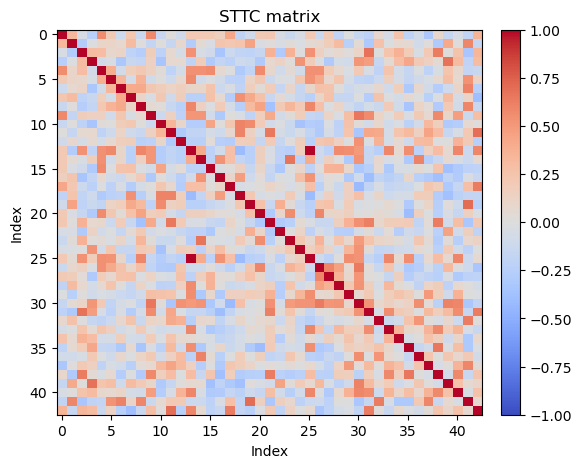

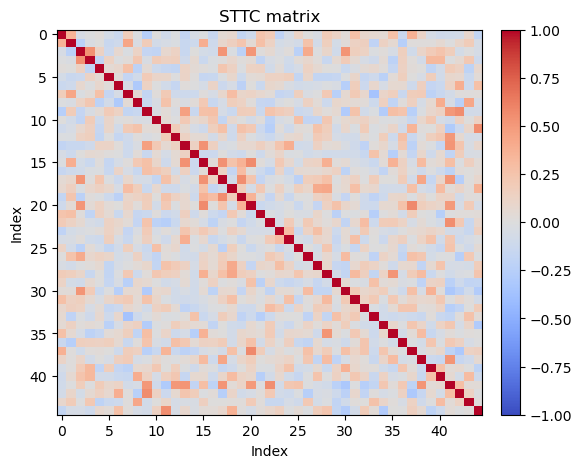

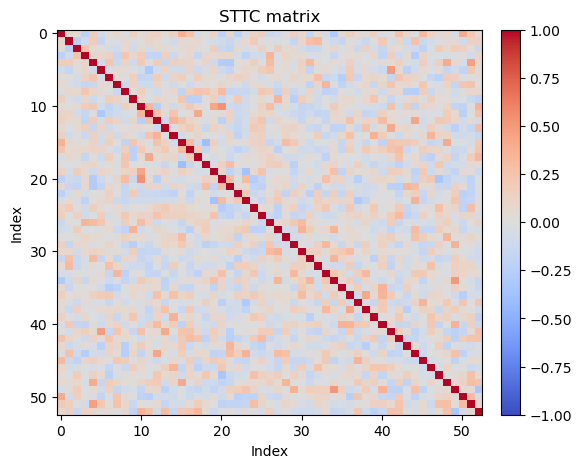

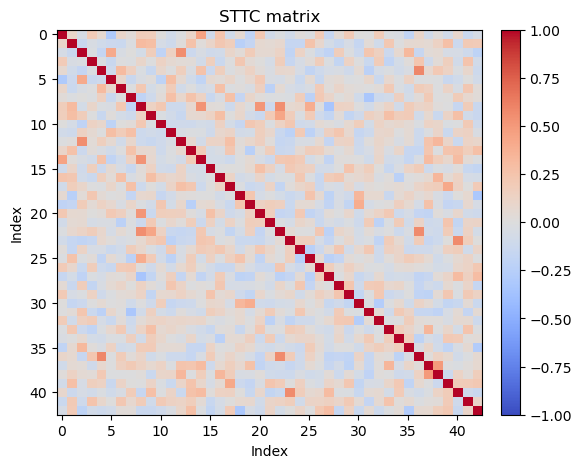

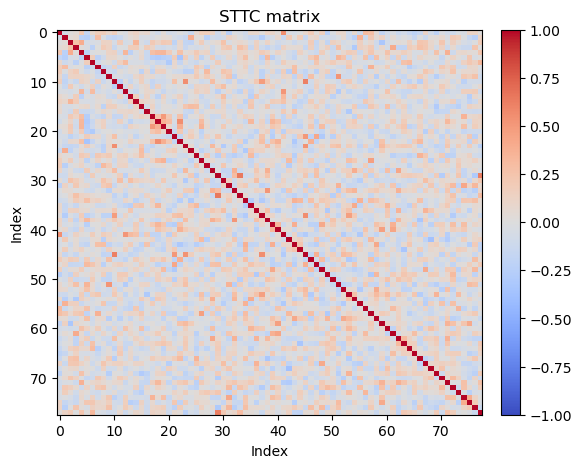

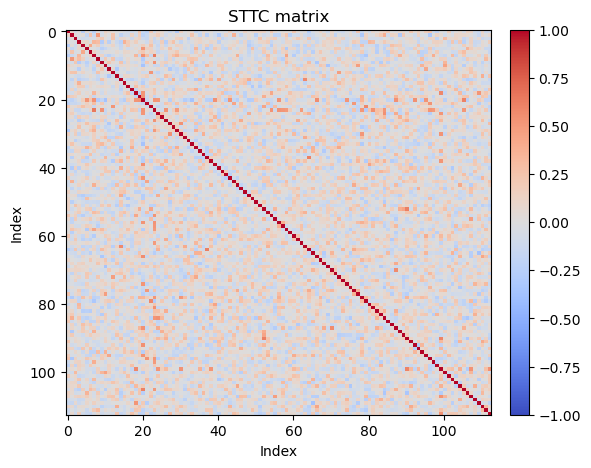

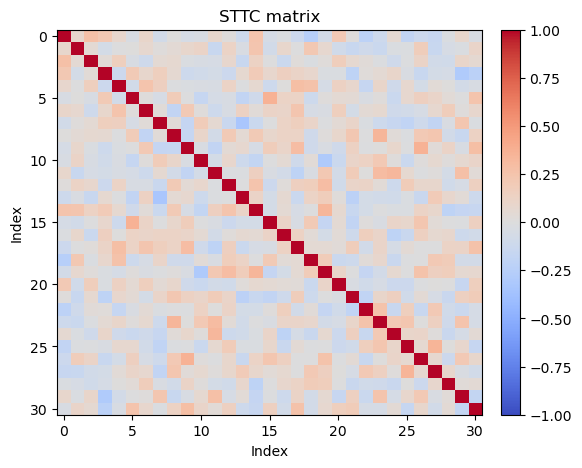

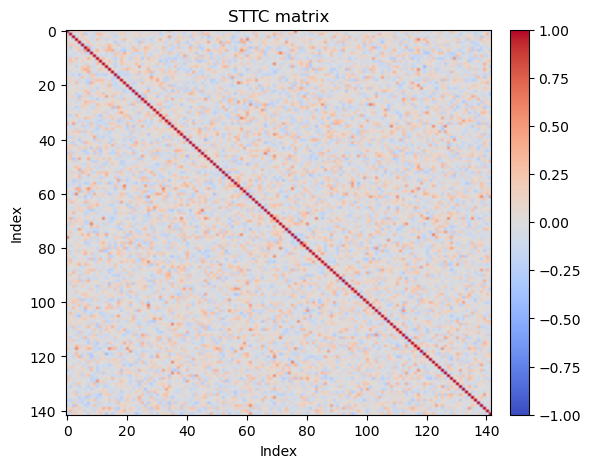

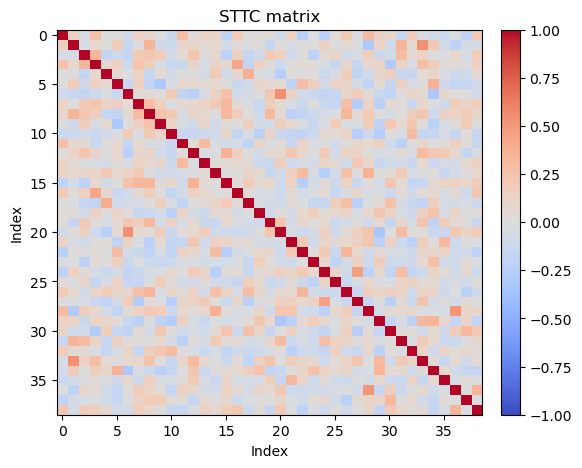

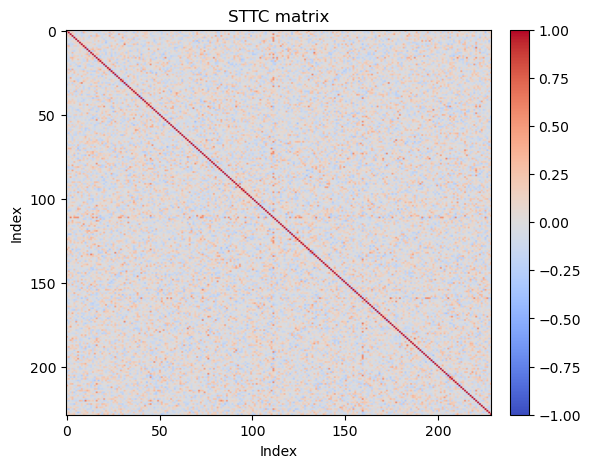

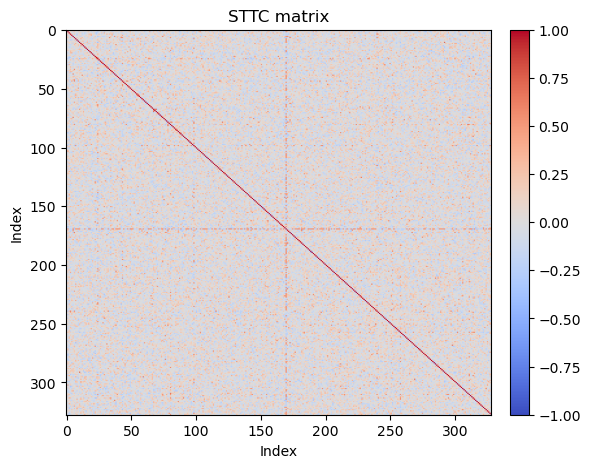

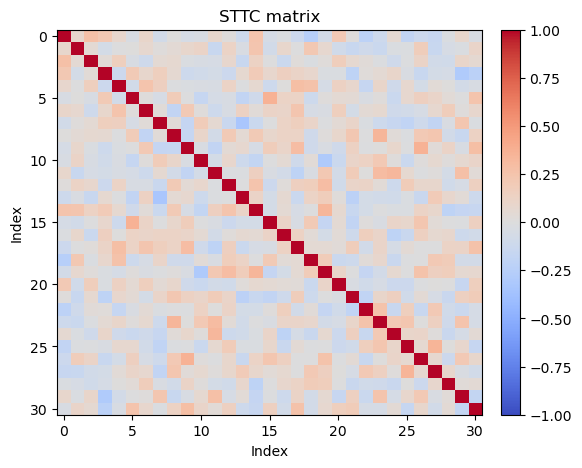

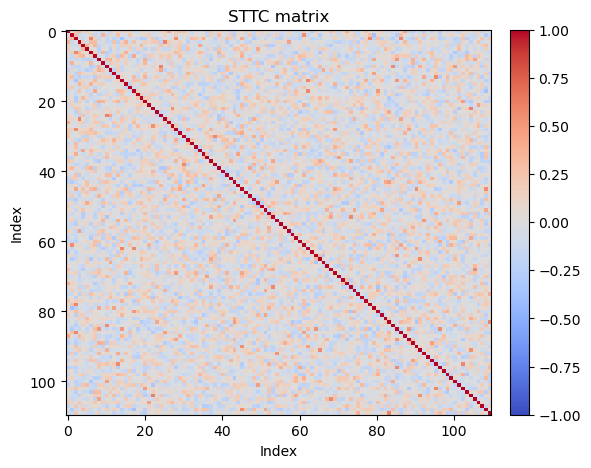

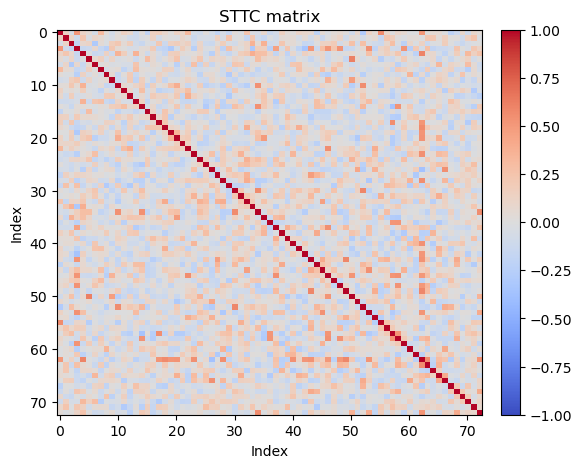

In [7]:
experiment_root = r"C:\Users\mzinn1\Desktop\test_tree\ex345"
processor = ExperimentProcessor(runner=runner, models=models, config=config, output_root=experiment_root)
processor.process_tree(tree, verbose=True)

In [8]:
comparer = ExperimentComparer(comparator=BasicSiblingComparator())
sibling_tables = comparer.compare_all(tree)
from experiments.io import save_node_level_comparisons_with_legend
save_node_level_comparisons_with_legend(
    root=tree,
    sibling_tables=sibling_tables,
    output_subdir="metrics",
    filename="sibling_comparisons.xlsx",
)
print("\n=== Sibling comparisons (by node) ===")
# Print the top-level node comparison if present
if experiment_root in sibling_tables:
    print(f"\nNode: {experiment_root}")
    print(sibling_tables[experiment_root].to_string(index=False))

# Print one level down comparisons too (often treatments)
for node_path, df in sibling_tables.items():
    if node_path == experiment_root:
        continue
    # keep output readable: only print “interesting” nodes
    if len(df) >= 2:
        print(f"\nNode: {node_path}")
        print(df.to_string(index=False))


=== Sibling comparisons (by node) ===

Node: C:\Users\mzinn1\Desktop\test_tree\ex345
                                 parent child  n_videos  n_neurons  decay_tau_mean_unweighted  decay_tau_var_unweighted  decay_tau_within_unweighted  decay_tau_between_unweighted  decay_tau_mean_weighted  decay_tau_var_weighted  decay_tau_within_weighted  decay_tau_between_weighted  f_value_mean_unweighted  f_value_var_unweighted  f_value_within_unweighted  f_value_between_unweighted  f_value_mean_weighted  f_value_var_weighted  f_value_within_weighted  f_value_between_weighted  half_max_width_mean_unweighted  half_max_width_var_unweighted  half_max_width_within_unweighted  half_max_width_between_unweighted  half_max_width_mean_weighted  half_max_width_var_weighted  half_max_width_within_weighted  half_max_width_between_weighted  rise_slope_mean_unweighted  rise_slope_var_unweighted  rise_slope_within_unweighted  rise_slope_between_unweighted  rise_slope_mean_weighted  rise_slope_var_weighted  rise_sl

In [ ]:
timepoint_path = Path(r"C:\Users\mzinn1\Desktop\test_notebook\week 2")
timepoint_obj = timepoint.Timepoint(timepoint_path)   
video_paths = [f for f in timepoint_path.iterdir() if f.is_dir()]
video_objs = [Video(vp, vp / "suite2p/plane0") for vp in video_paths]


In [4]:
def roi_aggregation(suite2p_data: dict, n_rois: int) -> list[roi.ROI]:  
    all_rois = []
    for i in range(n_rois):
        roi_obj = roi.ROI(
            index=i,
            f_trace=suite2p_data['F'][i],
            stats=suite2p_data['stat'][i] if 'stat' in suite2p_data else None,
            fneu=suite2p_data['Fneu'][i] if 'Fneu' in suite2p_data else None,
        )
        all_rois.append(roi_obj)
    return all_rois

In [5]:
for video in video_objs:
    norm_sm_f, norm_sg_f= video.process_fluorescence_traces()
    n_rois, n_frames = norm_sm_f.shape
    all_rois = roi_aggregation(video.suite2p_data, n_rois)
    good_rois, good_roi_masks = video.filter_rois(all_rois, models["roi_classifier"])
    filtered_suite2p_path = save_filtered_suite2p(video_path=video.path, good_roi_mask=good_roi_masks, 
                                                suite2p_data=video.suite2p_data)
    video.get_bad_rois_features_df()
    video.neurons = [neuron.Neuron(roi, i, fs = video.suite2p_data['ops']['fs']) for i, roi in enumerate(good_rois)]
    print(f"Video {video.path.name} processed. Filtered suite2p data saved to {Path(*filtered_suite2p_path.parts[-4:])}")
    print(f"\tGood ROIs: {len(good_rois)}, Bad ROIs: {len(video.bad_rois)}")

{'derivative_skew': 0.1475094089169334, 'derivative_asymmetry': 0.9983623026197584, 'spike_prom_mean': 0.01666051521897316, 'spike_prom_skew': 0.48369395791696, 'range_trace': 0.05109536647796631, 'var_of_var': 1.8188827858490485e-09, 'ac_decay': 0.22988266834381132, 'snr_estimate': 2.364223479711121, 'peak_density': 0.03222222222222222, 'median_spike_prom': 0.012320518493652344}
{'derivative_skew': 0.24340617787360763, 'derivative_asymmetry': 1.026068090007937, 'spike_prom_mean': 0.007077852729707956, 'spike_prom_skew': 0.9184123964401482, 'range_trace': 0.02247670292854309, 'var_of_var': 4.8489014112149e-11, 'ac_decay': 0.2718032356892429, 'snr_estimate': 2.4860924883508217, 'peak_density': 0.03777777777777778, 'median_spike_prom': 0.005141282454133034}
{'derivative_skew': -0.06290705194257853, 'derivative_asymmetry': 0.957493648076523, 'spike_prom_mean': 0.007704056333750486, 'spike_prom_skew': 0.5697659952328479, 'range_trace': 0.023707015439867973, 'var_of_var': 4.617664931218066e

In [6]:
for video in video_objs:
    spike_feats_df = video._extract_spike_features_parallel()
    neurons_with_spikes, spike_mask = video.filter_all_spikes(spike_feats_df, models['spike_classifier'])
    spike_summaries_per_neuron = video.get_spike_statistics()
    print(f"Spike statistics computed for video {video.path.name}.")
    candidate_spikes = len(spike_mask)
    positive_spikes = spike_mask.sum()
    print(f"\tClassified {positive_spikes} / {candidate_spikes} candidate spikes as true spikes.")

Spike statistics computed for video 2-1.
	Classified 1094 / 1702 candidate spikes as true spikes.
Spike statistics computed for video 2-1_5um_1m.
	Classified 989 / 1429 candidate spikes as true spikes.
Spike statistics computed for video 2-2.
	Classified 1095 / 1751 candidate spikes as true spikes.
Spike statistics computed for video 2-2_5um_3m.
	Classified 935 / 1449 candidate spikes as true spikes.
Spike statistics computed for video 2-3.
	Classified 1348 / 2175 candidate spikes as true spikes.
Spike statistics computed for video 2-3_5um_5m.
	Classified 2343 / 3493 candidate spikes as true spikes.
Spike statistics computed for video 2-4.
	Classified 492 / 846 candidate spikes as true spikes.
Spike statistics computed for video 2-4_50um_1m.
	Classified 405 / 698 candidate spikes as true spikes.


In [7]:
for video in video_objs:
    grouping_config = config["grouping"]["sttc"]
    time_window = grouping_config["time_window"]
    distance_threshold = grouping_config["distance_threshold"]

    grouping_stats, sttc_groups = video.get_group_summary(time_window, distance_threshold)
    video._visualize_neuron_groups(config_label="sttc")
    
    

In [8]:
for video in video_objs:
    video_stats = VideoStatistics.from_video(video)
    writer = VideoStatisticsWriter()
    manifest = writer.write(video_stats, video.path.parent)
    

In [ ]:
from pipeline.video_runner import VideoPipelineRunner
from pipeline.services import grouping_service, roi_service, spike_service, trace_service
video_path = Path(r"C:\Users\mzinn1\Desktop\test_notebook\week 2\2-4")
video = Video(path=video_path, suite2p_path=video_path / "suite2p/plane0")

runner = VideoPipelineRunner(
    trace=trace_service.TraceService(smooth_sigma=4.0, sensor_type="gcamp6s"),
    roi=roi_service.ROIService(n_jobs=-1),
    spike=spike_service.SpikeService(n_jobs=-1),
    grouping=grouping_service.GroupingService(enable_dtw=False),
)

runner.run(video, models=models, config=config)

stats = VideoStatistics.from_video(video)

VideoStatisticsWriter().write(stats, output_root=video.path.parent)



 Processing: 2-4
  Traces: 66 ROIs, 900 frames @ 15.0 Hz
  ROI filter: 32/66 kept (48.5%)
  Spikes: 492/846 kept | neurons 32 → 32
  Grouping (sttc): 0 groups | agreement=0.00


{'metrics_excel': 'C:\\Users\\mzinn1\\Desktop\\test_notebook\\week 2\\2-4\\metrics\\2-4_metrics.xlsx',
 'sttc_matrix_npy': 'C:\\Users\\mzinn1\\Desktop\\test_notebook\\week 2\\2-4\\metrics\\2-4_sttc_matrix.npy',
 'dtw_matrix_npy': 'C:\\Users\\mzinn1\\Desktop\\test_notebook\\week 2\\2-4\\metrics\\2-4_dtw_matrix.npy',
 'sttc_fig_png': 'C:\\Users\\mzinn1\\Desktop\\test_notebook\\week 2\\2-4\\metrics\\2-4_sttc_groups.png',
 'dtw_fig_png': 'C:\\Users\\mzinn1\\Desktop\\test_notebook\\week 2\\2-4\\metrics\\2-4_dtw_groups.png'}